# 01 — Exploratory Analysis: Recidivism Risk Scoring Data

**Dataset:** COMPAS recidivism risk scores for defendants in Broward County, Florida,
originally compiled and released by ProPublica for their 2016 investigation
["Machine Bias"](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing).
This is the canonical public dataset used throughout the algorithmic-fairness research
literature (Chouldechova 2017; Kleinberg, Mullainathan & Raghavan 2016; Dressel & Farid 2018).

Each row is one defendant: their COMPAS-assigned risk score (`decile_score` 1-10,
`score_text` Low/Medium/High), whether they actually reoffended within two years
(`two_year_recid`, the ground truth), and demographic/case attributes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (9, 4)

df = pd.read_csv("../data/raw/compas_scores.csv")
print(df.shape)
df.head()

(5278, 8)


,two_year_recid,score_text,decile_score,race,age_cat,c_charge_degree,sex,priors_count
0,1,Low,3,African-American,25 - 45,F,Male,0
1,1,Low,4,African-American,Less than 25,F,Male,4
2,1,Medium,6,Caucasian,25 - 45,F,Male,14
3,0,Low,1,Caucasian,25 - 45,M,Female,0
4,0,Low,4,Caucasian,25 - 45,F,Male,0


## Class balance and demographics

In [2]:
print("Two-year recidivism rate (overall):", df["two_year_recid"].mean().round(4))
print()
print(df["race"].value_counts())
print()
print(df["sex"].value_counts())
print()
print(df["age_cat"].value_counts())

Two-year recidivism rate (overall): 0.4704

race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

sex
Male      4247
Female    1031
Name: count, dtype: int64

age_cat
25 - 45            3026
Less than 25       1156
Greater than 45    1096
Name: count, dtype: int64


## Recidivism base rate by race

This is NOT itself evidence of bias in the *tool* — base rates differing across
groups is a documented feature of the underlying arrest data, shaped by decades of
policing patterns. What matters for a fairness audit is how the tool's *errors* are
distributed relative to those base rates, examined in `02_bias_audit.ipynb`.

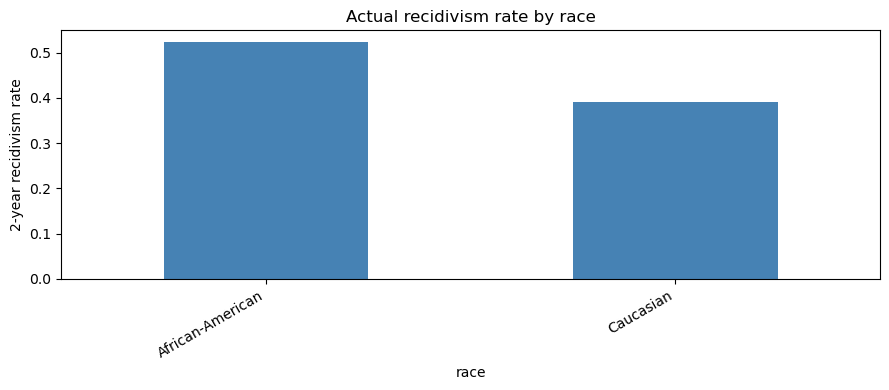

In [3]:
fig, ax = plt.subplots()
df.groupby("race")["two_year_recid"].mean().sort_values(ascending=False).plot(kind="bar", ax=ax, color="steelblue")
ax.set_ylabel("2-year recidivism rate")
ax.set_title("Actual recidivism rate by race")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Risk score distribution by race

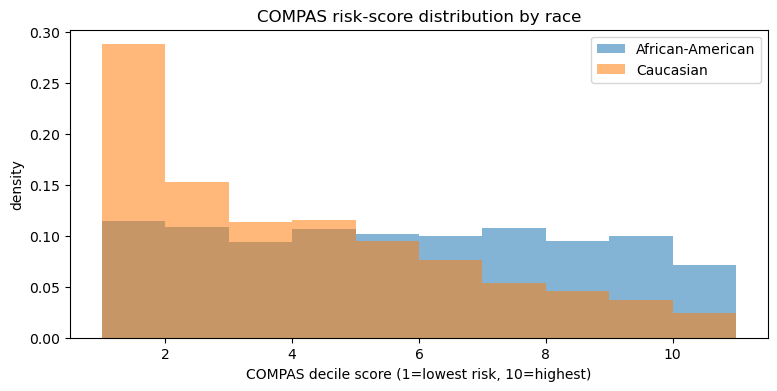

In [4]:
fig, ax = plt.subplots()
for race, sub in df[df["race"].isin(["African-American", "Caucasian"])].groupby("race"):
    ax.hist(sub["decile_score"], bins=range(1, 12), alpha=0.55, label=race, density=True)
ax.set_xlabel("COMPAS decile score (1=lowest risk, 10=highest)")
ax.set_ylabel("density")
ax.set_title("COMPAS risk-score distribution by race")
ax.legend()
plt.show()

## Prior record by race

`priors_count` is one of the strongest predictors of the score, and of actual
recidivism. It's also a channel through which race-correlated policing history can
enter a model even when race itself is excluded as a feature — relevant for the
mitigation notebook.

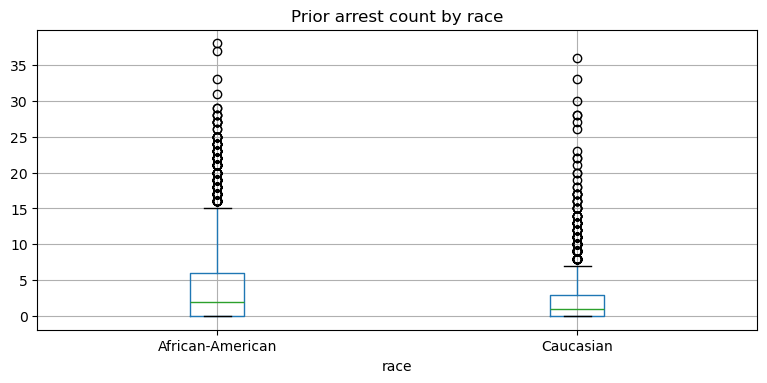

race
African-American    2.0
Caucasian           1.0
Name: priors_count, dtype: float64


In [5]:
fig, ax = plt.subplots()
df[df["race"].isin(["African-American","Caucasian"])].boxplot(column="priors_count", by="race", ax=ax)
ax.set_title("Prior arrest count by race")
plt.suptitle("")
plt.show()

print(df.groupby("race")["priors_count"].median())

## Takeaways

- Recidivism base rates and prior-record distributions differ by race in this data —
  a structural fact about the criminal justice system, not something this audit can
  or should paper over.
- The open question for a fairness audit is whether the COMPAS score's **errors**
  (false positives, false negatives) are distributed proportionally to those base
  rates, or whether one group is disproportionately mis-flagged. That's the subject
  of `02_bias_audit.ipynb`.